<a href="https://colab.research.google.com/github/Nisa-a/EDI-Dashboard/blob/main/Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import shap

from collections import Counter
from imblearn.over_sampling import RandomOverSampler

!pip install catboost
from catboost import CatBoostClassifier, CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report)

!pip install scipy
from scipy.stats import chi2_contingency

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.7 MB/s eta 0:00:00


In [2]:
# Load data
df = pd.read_csv('/content/preprocessed_student_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COURSETITLE         2528 non-null   object 
 1   MODULENAME          2528 non-null   object 
 2   CREDITS             2528 non-null   int64  
 3   LEVEL               2528 non-null   int64  
 4   SEMESTER            2528 non-null   object 
 5   SEX                 2528 non-null   object 
 6   ETHNICITY           2528 non-null   object 
 7   DISABLETYPE         2528 non-null   object 
 8   CARELEAVER          2528 non-null   object 
 9   IMDQUINTILE         2528 non-null   object 
 10  ACCOMMODATIONTYPE   2528 non-null   object 
 11  COMMUTELENGTH       2528 non-null   object 
 12  OFSENTQUALGRPLABEL  2528 non-null   object 
 13  TARIFFPOINTS        2528 non-null   int64  
 14  STATEMARKERLABEL    2528 non-null   object 
 15  SCHOLARSHIPANY      2528 non-null   object 
 16  GREATS

In [3]:
# View distribution of module grades.
histplot = px.histogram(df, x='MODULEGRADE')
histplot.show()

In [4]:
# View distribution of classification.
barplot = px.bar(df, x='CLASSIFICATION')
barplot.show()

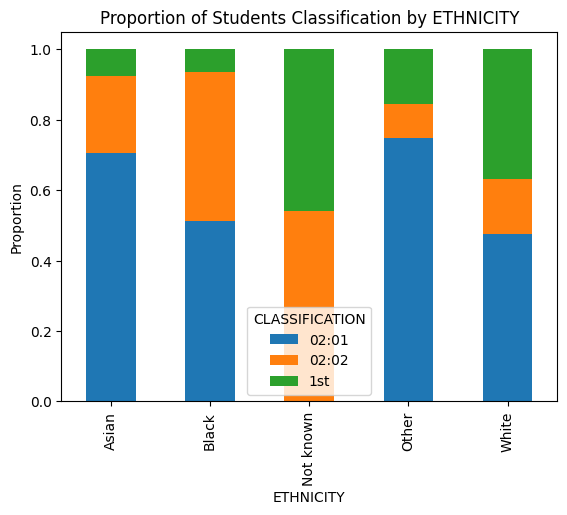

In [5]:
# Visualise the proportion of classififcation by ETHNICITY.
pd.crosstab(
    df['ETHNICITY'],
    df['CLASSIFICATION'],
    normalize='index'
).plot(kind='bar', stacked=True)

plt.ylabel('Proportion')
plt.xlabel('ETHNICITY')
plt.title('Proportion of Students Classification by ETHNICITY')
plt.show()

In [6]:
# Prep for modelling:
# Define variables.
X_all = df.drop(columns=['CLASSIFICATION', 'MODULEGRADE'])
y_class = df['CLASSIFICATION']

# Split dataset for training and testing.
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_class, test_size=0.2, random_state=42, stratify=y_class
)

In [7]:
# Balance the classes by oversampling the minority class.
oversample = RandomOverSampler(sampling_strategy='not majority', random_state=42)
X_train_balanced, y_train_balanced = oversample.fit_resample(X_train, y_train)

print("Original class distribution:", Counter(y_class))
print("Resampled training distribution:", Counter(y_train_balanced))

# This code cell is adapted from:
# GeeksforGeeks, 2026. Handling Imbalanced Data for Classification. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-imbalanced-data-for-classification/

Original class distribution: Counter({'02:01': 1545, '02:02': 517, '1st': 466})
Resampled training distribution: Counter({'02:02': 1236, '1st': 1236, '02:01': 1236})


In [8]:
# Build the model for original dataset:
# Extract only categorical columns.
cat_features = X_train_balanced.select_dtypes(include=['object']).columns.tolist()
# Limit one-hot encoding for categorical features with up to 10 unique values.
one_hot_max_size = 10
# Initialize the CatBoostClassifier.
all_var_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                           verbose=False, cat_features= cat_features,
                                   one_hot_max_size= one_hot_max_size)

# This code cell is adapted from:
# GeeksforGeeks, 2025. Handling categorical features with CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-categorical-features-with-catboost/

In [9]:
# Train model.
all_var_model.fit( X_train_balanced, y_train_balanced)

CatBoostClassifier(cat_features=['COURSETITLE', 'MODULENAME', 'SEMESTER', 'SEX', 'ETHNICITY', 'DISABLETYPE', 'CARELEAVER', 'IMDQUINTILE', 'ACCOMMODATIONTYPE', 'COMMUTELENGTH', 'OFSENTQUALGRPLABEL', 'STATEMARKERLABEL', 'SCHOLARSHIPANY', 'GREATSTARTACCESS', 'BURSARY', 'ASSTYPENAME', 'AGEGROUP'], depth=6, iterations=100, learning_rate=0.1, one_hot_max_size=10, verbose=False)

In [10]:
# Evaluate  model.
y_pred = all_var_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9683794466403162
              precision    recall  f1-score   support

       02:01       0.97      0.97      0.97       309
       02:02       0.93      0.99      0.96       104
         1st       1.00      0.92      0.96        93

    accuracy                           0.97       506
   macro avg       0.97      0.96      0.96       506
weighted avg       0.97      0.97      0.97       506



In [11]:
# Display the importance of each feature.
all_var_importance = all_var_model.get_feature_importance()
all_var_importance_table = pd.DataFrame({
    'feature': X_train_balanced.columns,
    'importance': all_var_importance
}).sort_values(by='importance', ascending=False)

print(all_var_importance_table)

# This code cell is adapted from:
# CatBoost, 2026. CatBoostClassifier. [Online]
# Available at: https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier#cat_features

               feature  importance
13        TARIFFPOINTS   17.668424
6            ETHNICITY   13.828920
9          IMDQUINTILE   13.792699
12  OFSENTQUALGRPLABEL   13.056714
10   ACCOMMODATIONTYPE    9.648569
0          COURSETITLE    8.562484
11       COMMUTELENGTH    6.834834
14    STATEMARKERLABEL    4.332530
8           CARELEAVER    3.730673
16    GREATSTARTACCESS    3.441659
17             BURSARY    2.347380
7          DISABLETYPE    1.040948
5                  SEX    0.897549
22            AGEGROUP    0.716489
15      SCHOLARSHIPANY    0.070253
1           MODULENAME    0.029875
3                LEVEL    0.000000
2              CREDITS    0.000000
4             SEMESTER    0.000000
18         ASSTYPENAME    0.000000
19             ASSPERC    0.000000
20               HASMC    0.000000
21          ACCEPTEDMC    0.000000


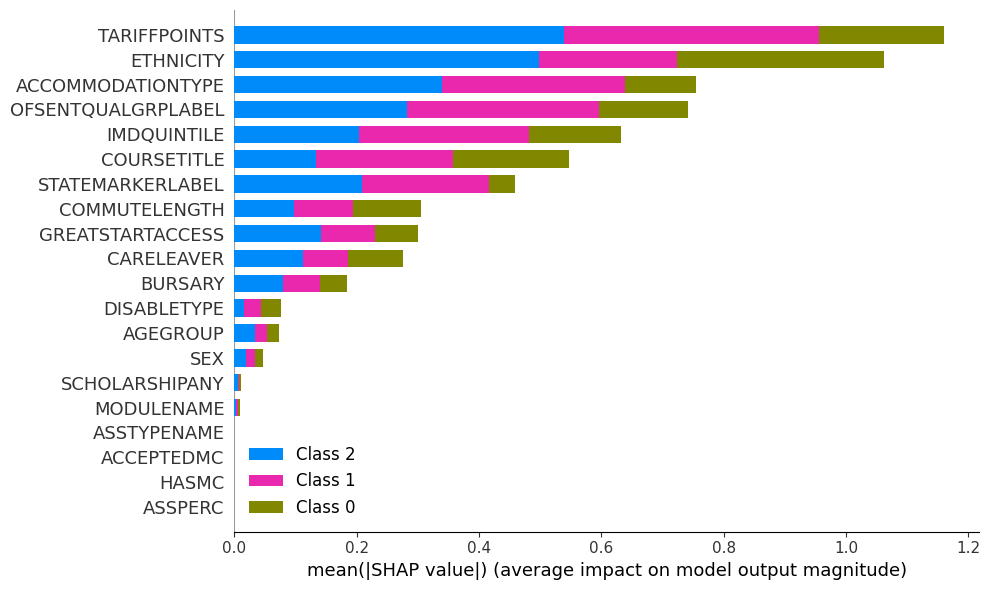

In [12]:
# Further visualise feature importance using SHAP.
# Initialize explainer for model.
explainer = shap.Explainer(all_var_model)
# Calculate SHAP values for classification test set.
shap_values = explainer.shap_values(X_test)

# Create a summary plot.
shap.summary_plot(shap_values, X_test, plot_type="bar", plot_size= (10,6))
plt.show()

# This code cell is adapted from:
# GeeksforGeeks, 2025. Handling categorical features with CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-categorical-features-with-catboost/

In [13]:
# Create a EDI-focus dataset
# Load in pre-processed dataset.
edi_df = pd.read_csv('/content/preprocessed_student_data.csv')
# Drop variables that had < 0.5 improtance:
edi_df.drop(['SCHOLARSHIPANY','MODULENAME','HASMC',
             'ASSTYPENAME','ASSPERC','ACCEPTEDMC',
             'LEVEL','SEMESTER','CREDITS'], axis= 1, inplace= True)
edi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2528 entries, 0 to 2527
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   COURSETITLE         2528 non-null   object 
 1   SEX                 2528 non-null   object 
 2   ETHNICITY           2528 non-null   object 
 3   DISABLETYPE         2528 non-null   object 
 4   CARELEAVER          2528 non-null   object 
 5   IMDQUINTILE         2528 non-null   object 
 6   ACCOMMODATIONTYPE   2528 non-null   object 
 7   COMMUTELENGTH       2528 non-null   object 
 8   OFSENTQUALGRPLABEL  2528 non-null   object 
 9   TARIFFPOINTS        2528 non-null   int64  
 10  STATEMARKERLABEL    2528 non-null   object 
 11  GREATSTARTACCESS    2528 non-null   object 
 12  BURSARY             2528 non-null   object 
 13  CLASSIFICATION      2528 non-null   object 
 14  MODULEGRADE         2528 non-null   float64
 15  AGEGROUP            2528 non-null   object 
dtypes: flo

In [14]:
# Save the EDI dataset
edi_df.to_csv("edi_df.csv", index=False)

In [15]:
# Model for EDI dataset:
# Define variables.
X_edi = edi_df.drop(columns=['CLASSIFICATION', 'MODULEGRADE'])
y_edi_class = edi_df['CLASSIFICATION']

# Split dataset
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X_edi, y_edi_class, test_size=0.25, random_state=42, stratify=y_edi_class
)

In [16]:
# Extract only categorical columns.
cat_features1 = X1_train.select_dtypes(include=['object']).columns.tolist()
# Limit one-hot encoding for categorical features with up to 10 unique values.
one_hot_max_size = 10
# Initialize the CatBoostClassifier.
# Use cat_features1 instead of cat_features
edi_model = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1,
                           verbose=False, cat_features= cat_features1, one_hot_max_size= one_hot_max_size)

# This code cell is adapted from:
# GeeksforGeeks, 2025. Handling categorical features with CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-categorical-features-with-catboost/

In [17]:
# Train EDI model.
edi_model.fit( X1_train, y1_train)

CatBoostClassifier(cat_features=['COURSETITLE', 'SEX', 'ETHNICITY', 'DISABLETYPE', 'CARELEAVER', 'IMDQUINTILE', 'ACCOMMODATIONTYPE', 'COMMUTELENGTH', 'OFSENTQUALGRPLABEL', 'STATEMARKERLABEL', 'GREATSTARTACCESS', 'BURSARY', 'AGEGROUP'], depth=6, iterations=100, learning_rate=0.1, one_hot_max_size=10, verbose=False)

In [18]:
# Evaluate model
y1_pred = edi_model.predict(X1_test)
print("EDI Accuracy:", accuracy_score(y1_test, y1_pred))
print(classification_report(y1_test, y1_pred))

EDI Accuracy: 0.9746835443037974
              precision    recall  f1-score   support

       02:01       0.96      0.99      0.98       386
       02:02       0.98      0.96      0.97       129
         1st       1.00      0.92      0.96       117

    accuracy                           0.97       632
   macro avg       0.98      0.96      0.97       632
weighted avg       0.98      0.97      0.97       632



In [20]:
# Display the importance of each feature.
edi_importance = edi_model.get_feature_importance()
edi_importance_table = pd.DataFrame({
    'feature': X1_train.columns,
    'importance': edi_importance
}).sort_values(by='importance', ascending=False)

print(edi_importance_table)

# This code cell is adapted from:
# CatBoost, 2026. CatBoostClassifier. [Online]
# Available at: https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier#cat_features

               feature  importance
9         TARIFFPOINTS   14.050960
8   OFSENTQUALGRPLABEL   13.906296
2            ETHNICITY   13.203891
5          IMDQUINTILE   12.383663
0          COURSETITLE   10.709997
6    ACCOMMODATIONTYPE   10.431700
7        COMMUTELENGTH    7.461114
12             BURSARY    4.346217
10    STATEMARKERLABEL    3.920794
4           CARELEAVER    3.348905
11    GREATSTARTACCESS    2.822274
3          DISABLETYPE    1.447544
1                  SEX    1.068577
13            AGEGROUP    0.898067


In [21]:
# Regression CatBoost model for Module Grade.
# Define variables.
X2 = edi_df.drop(columns=['CLASSIFICATION', 'MODULEGRADE'])
y2 = edi_df['MODULEGRADE']

# Split data.
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.25, random_state=42
)

In [22]:
# Extract only categorical columns.
cat_features2 = X2_train.select_dtypes(include=['object']).columns.tolist()
# Limit one-hot encoding for categorical features with up to 10 unique values.
one_hot_max_size = 10
# Initialize the CatBoostRegressor with RMSE as the loss function.
edi_reg_model = CatBoostRegressor(loss_function='RMSE',
                                  cat_features= cat_features2,
                                  one_hot_max_size= one_hot_max_size)

# Fit the model on the training data with verbose logging every 100 iterations
edi_reg_model.fit(X2_train, y2_train, verbose=100)

# This code cell is adapted from:
# GeeksforGeeks, 2025. Handling categorical features with CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-categorical-features-with-catboost/

# GeeksforGeeks, 2025. Regression using CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/regression-using-catboost/

Learning rate set to 0.045298
0:	learn: 9.5464334	total: 978us	remaining: 978ms
100:	learn: 9.3043125	total: 60ms	remaining: 534ms
200:	learn: 9.1861801	total: 120ms	remaining: 476ms
300:	learn: 9.1205267	total: 181ms	remaining: 421ms
400:	learn: 9.0928347	total: 243ms	remaining: 364ms
500:	learn: 9.0811525	total: 303ms	remaining: 302ms
600:	learn: 9.0756030	total: 372ms	remaining: 247ms
700:	learn: 9.0720086	total: 434ms	remaining: 185ms
800:	learn: 9.0701698	total: 502ms	remaining: 125ms
900:	learn: 9.0690599	total: 575ms	remaining: 63.1ms
999:	learn: 9.0683633	total: 647ms	remaining: 0us


CatBoostRegressor(cat_features=['COURSETITLE', 'SEX', 'ETHNICITY', 'DISABLETYPE', 'CARELEAVER', 'IMDQUINTILE', 'ACCOMMODATIONTYPE', 'COMMUTELENGTH', 'OFSENTQUALGRPLABEL', 'STATEMARKERLABEL', 'GREATSTARTACCESS', 'BURSARY', 'AGEGROUP'], loss_function='RMSE', one_hot_max_size=10)

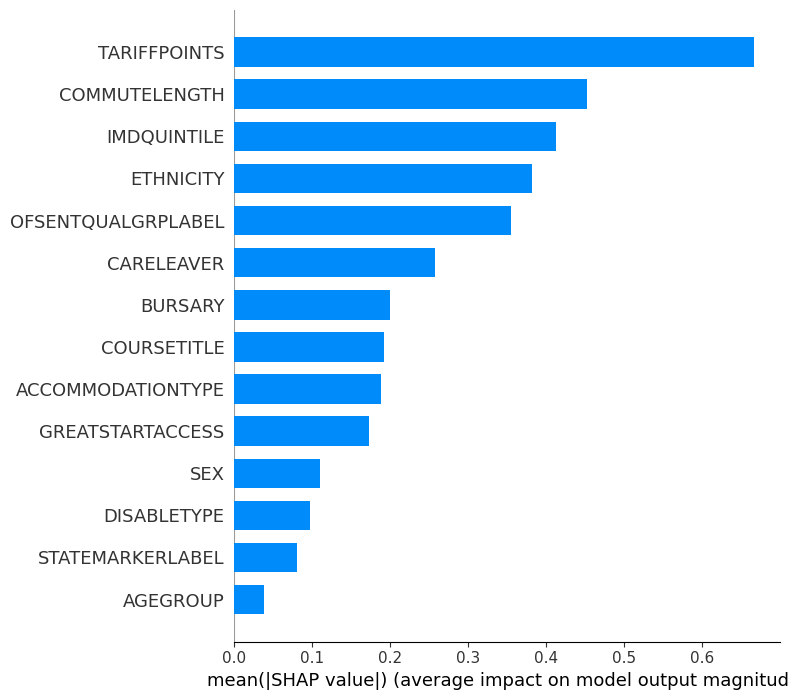

In [24]:
# use SHAP for regression model.
# Initialize explainer for the regression model.
explainer2 = shap.Explainer(edi_reg_model)
# Calculate SHAP values for the regression test set.
edi_reg_shap_values = explainer2.shap_values(X2_test)

# Create a summary plot.
shap.summary_plot(edi_reg_shap_values, X2_test, plot_type="bar")
plt.show()

# This code cell is adapted from:
# GeeksforGeeks, 2025. Handling categorical features with CatBoost. [Online]
# Available at: https://www.geeksforgeeks.org/machine-learning/handling-categorical-features-with-catboost/

In [ ]:
# Chi - square test:
# Store testing results
edi_results = []
# Define the target variable
target = 'CLASSIFICATION'
# Select the categorical variables
categorical_cols = edi_df.select_dtypes(include='object').columns
# create a loop to go through each variable
for col in categorical_cols:
    if col != target: # Skip the target variable when going through loop.
        ct = pd.crosstab(edi_df[col], edi_df[target]) # Define the table.
        stat, p, dof, expected = chi2_contingency(ct) # Run Chi-sqaure test.
        # interpret p-value
        if p < 0.05:
            result = "Significant"
        else:
            result = "Not Significant"
        # Make the results into a list.
        edi_results.append({
            'Variable': col,
            'p-value': p,
            'Result': result
        })
# Make a dataframe to store and sort the results.
edi_results_df = pd.DataFrame(edi_results).sort_values(by='p-value')
# Display results
print(edi_results_df)

# This code cell is adapted from:
# GeeksforGeeks, 2025. Python - Pearson's Chi-Square Test. [Online]
# Available at: https://www.geeksforgeeks.org/python/python-pearsons-chi-square-test/

              Variable        p-value       Result
8   OFSENTQUALGRPLABEL  6.344488e-130  Significant
2            ETHNICITY   5.451984e-85  Significant
7        COMMUTELENGTH   6.134477e-50  Significant
5          IMDQUINTILE   3.212510e-46  Significant
3          DISABLETYPE   1.423286e-42  Significant
6    ACCOMMODATIONTYPE   3.062615e-39  Significant
12            AGEGROUP   1.887710e-38  Significant
9     STATEMARKERLABEL   1.762007e-37  Significant
10    GREATSTARTACCESS   2.335493e-30  Significant
0          COURSETITLE   3.593384e-30  Significant
4           CARELEAVER   3.035880e-28  Significant
11             BURSARY   8.685763e-20  Significant
1                  SEX   6.945167e-06  Significant


In [60]:
# Merge significance and importance results.
merged_results = edi_results_df.merge(
    edi_importance_table,
    left_on='Variable',
    right_on='feature'
)
# Save merged results.
merged_results.to_csv('merged_results.csv', index=False)